In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
data = pd.read_csv("/home/user/Documents/Data science projects/HR project/HR_comma_sep.csv")

print(data.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

In [6]:
print("Dataset Shape")
print(data.shape)

print("\nColumns")
print(data.columns)

print("\nMissing Values")
print(data.isnull().sum())

Dataset Shape
(14999, 10)

Columns
Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

Missing Values
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64


In [9]:
le_Department = LabelEncoder()

data['Department'] = le_Department.fit_transform(data['Department'])

le_salary = LabelEncoder()

data['salary'] = le_salary.fit_transform(data['salary'])

print(data.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  Department  \
0                   3              0     1                      0           7   
1                   6              0     1                      0           7   
2                   4              0     1                      0           7   
3                   5              0     1                      0           7   
4                   3              0     1                      0           7   

   salary  
0       1  
1       

In [17]:
# Removing weak columns

X = data.drop(
    ['left', 'last_evaluation', 'Department'],
    axis=1
)

y = data['left']

print(X.head())
y = data['left']

print(X.head())

print(y.head())

   satisfaction_level  number_project  average_montly_hours  \
0                0.38               2                   157   
1                0.80               5                   262   
2                0.11               7                   272   
3                0.72               5                   223   
4                0.37               2                   159   

   time_spend_company  Work_accident  promotion_last_5years  salary  
0                   3              0                      0       1  
1                   6              0                      0       2  
2                   4              0                      0       2  
3                   5              0                      0       1  
4                   3              0                      0       1  
   satisfaction_level  number_project  average_montly_hours  \
0                0.38               2                   157   
1                0.80               5                   262   
2           

In [18]:
print(data.corr())

                       satisfaction_level  last_evaluation  number_project  \
satisfaction_level               1.000000         0.105021       -0.142970   
last_evaluation                  0.105021         1.000000        0.349333   
number_project                  -0.142970         0.349333        1.000000   
average_montly_hours            -0.020048         0.339742        0.417211   
time_spend_company              -0.100866         0.131591        0.196786   
Work_accident                    0.058697        -0.007104       -0.004741   
left                            -0.388375         0.006567        0.023787   
promotion_last_5years            0.025605        -0.008684       -0.006064   
Department                       0.003153         0.007772        0.009268   
salary                           0.011754         0.013965        0.009672   

                       average_montly_hours  time_spend_company  \
satisfaction_level                -0.020048           -0.100866   
last_ev

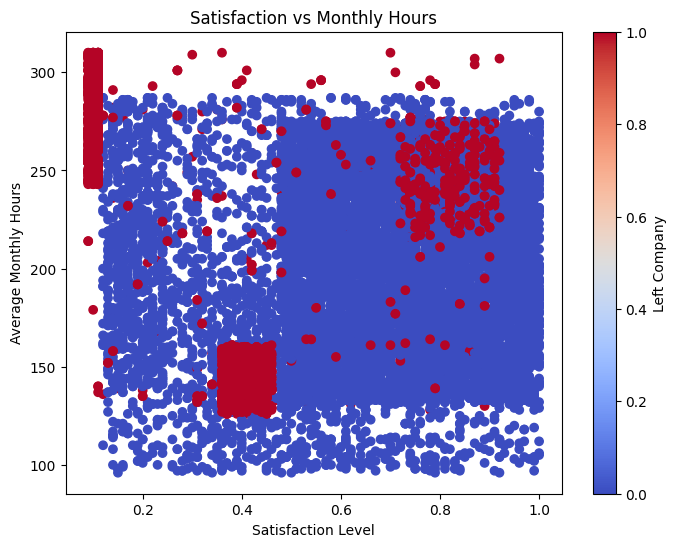

In [19]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    data['satisfaction_level'],
    data['average_montly_hours'],
    c=data['left'],
    cmap='coolwarm'
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Average Monthly Hours")

plt.title("Satisfaction vs Monthly Hours")

plt.colorbar(scatter, label='Left Company')

plt.show()

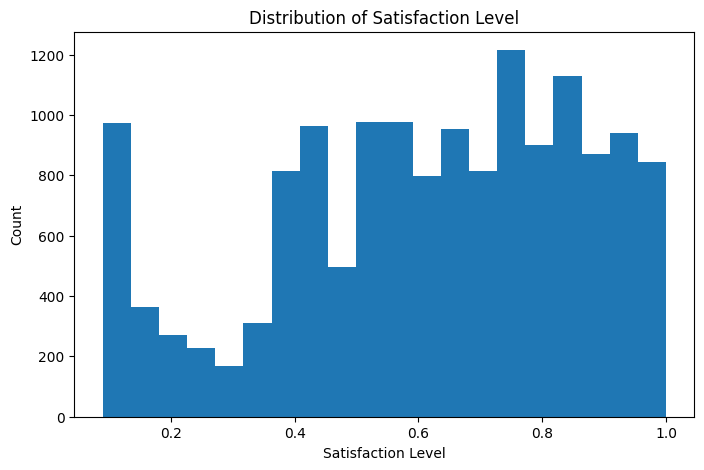

In [20]:
plt.figure(figsize=(8,5))

plt.hist(data['satisfaction_level'], bins=20)

plt.xlabel("Satisfaction Level")
plt.ylabel("Count")

plt.title("Distribution of Satisfaction Level")

plt.show()

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-0.93649469 -1.46286291 -0.88203988 ... -0.41116529 -0.14741182
  -0.55495458]
 [ 0.75281433  0.97111292  1.22042276 ... -0.41116529 -0.14741182
   1.04300352]
 [-2.02247906  2.59376348  1.4206573  ... -0.41116529 -0.14741182
   1.04300352]
 ...
 [-0.97671633 -1.46286291 -1.16236823 ... -0.41116529 -0.14741182
  -0.55495458]
 [-2.02247906  1.7824382   1.58084493 ... -0.41116529 -0.14741182
  -0.55495458]
 [-0.97671633 -1.46286291 -0.86201642 ... -0.41116529 -0.14741182
  -0.55495458]]


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(11999, 7)
(3000, 7)


In [23]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
linear_pred = linear_model.predict(X_test)

print(linear_pred[:10])

[ 0.02310498  0.03345388  0.19574064  0.39593083 -0.10445207  0.21725673
 -0.19105425  0.66009924  0.3685387   0.55801168]


In [25]:
linear_pred = [1 if i > 0.5 else 0 for i in linear_pred]

print(linear_pred[:10])

[0, 0, 0, 0, 0, 0, 0, 1, 0, 1]


In [26]:
linear_accuracy = accuracy_score(
    y_test,
    linear_pred
)

print("Linear Regression Accuracy")
print(linear_accuracy)

Linear Regression Accuracy
0.765


In [27]:
logistic_model = LogisticRegression(
    max_iter=2000
)

logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
logistic_pred = logistic_model.predict(X_test)

print(logistic_pred[:10])

[0 0 0 0 0 0 0 1 0 1]


In [29]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Accuracy")
print(logistic_accuracy)

Logistic Regression Accuracy
0.7563333333333333


In [30]:
cm = confusion_matrix(
    y_test,
    logistic_pred
)

print(cm)

[[2107  187]
 [ 544  162]]


In [31]:
print(classification_report(
    y_test,
    logistic_pred
))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85      2294
           1       0.46      0.23      0.31       706

    accuracy                           0.76      3000
   macro avg       0.63      0.57      0.58      3000
weighted avg       0.72      0.76      0.72      3000



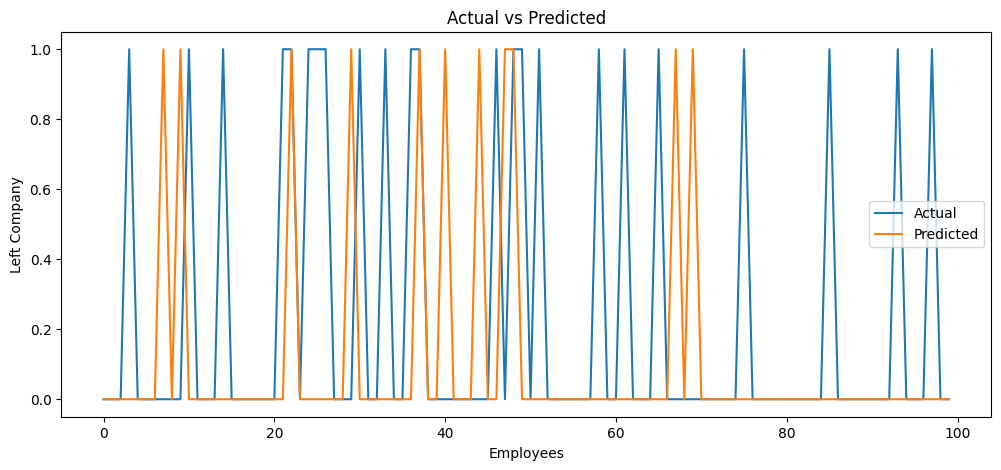

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    logistic_pred[:100],
    label='Predicted'
)

plt.xlabel("Employees")
plt.ylabel("Left Company")

plt.title("Actual vs Predicted")

plt.legend()

plt.show()

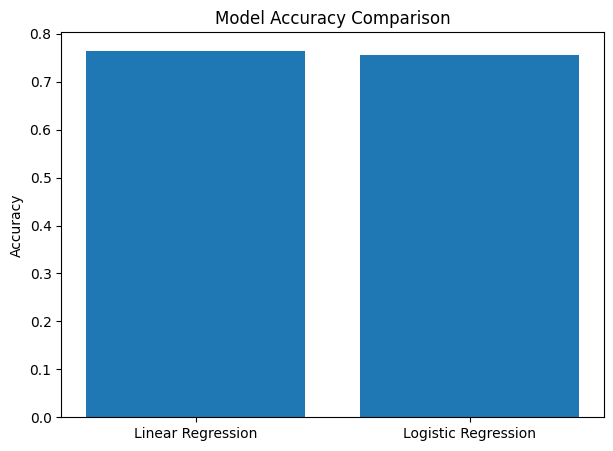

In [33]:
models = [
    'Linear Regression',
    'Logistic Regression'
]

accuracies = [
    linear_accuracy,
    logistic_accuracy
]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

In [34]:
print("Linear Regression Accuracy")
print(linear_accuracy)

print("\nLogistic Regression Accuracy")
print(logistic_accuracy)

if logistic_accuracy > linear_accuracy:
    print("\nLogistic Regression gives better accuracy")

else:
    print("\nLinear Regression gives better accuracy")

Linear Regression Accuracy
0.765

Logistic Regression Accuracy
0.7563333333333333

Linear Regression gives better accuracy
